# Sinhala → SSL Translation — Separate Decoder Vocabulary
## Architecture: XLM-RoBERTa Encoder + Custom SSL-Only Decoder Vocab
---
**Key difference from previous version:**
- Encoder input : XLM-RoBERTa tokenizer (250k vocab) — understands Sinhala
- Decoder output: SSL-only vocabulary (~1,200 tokens) — **cannot predict outside SSL**
- Model is architecturally impossible to output any non-SSL token


In [1]:
!pip install transformers sentencepiece -q

import torch
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print("VRAM    :", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
import os

class CFG:
    # ── Paths ──────────────────────────────────────────────────────────
    CORPUS_FILE   = "/kaggle/input/datasets/nadeenudantha/full-corpus3/full-corpus3.txt"
    OUTPUT_DIR    = "/kaggle/working"
    MODEL_DIR     = "/kaggle/working/models"
    LOG_FILE      = "/kaggle/working/training_log.csv"

    # ── Encoder: M2M100 (input side only) ─────────────────────────
    ENCODER_MODEL = "facebook/m2m100_418M"
    ENC_DIM       = 1024
    SRC_LANG      = "si"

    # ── Decoder: SSL-only vocabulary (output side) ─────────────────────
    PAD_IDX  = 0
    BOS_IDX  = 1
    EOS_IDX  = 2
    UNK_IDX  = 3
    OFFSET   = 4

    D_MODEL      = 512
    N_HEADS      = 8
    N_DEC_LAYERS = 4
    DIM_FFN      = 2048
    DROPOUT      = 0.1
    MAX_SRC_LEN  = 64
    MAX_TGT_LEN  = 48

    # ── Training ───────────────────────────────────────────────────────
    EPOCHS       = 50
    BATCH_SIZE   = 8
    ENCODER_LR   = 1e-5
    DECODER_LR   = 5e-4
    WEIGHT_DECAY = 1e-2
    WARMUP_RATIO = 0.1
    GRAD_CLIP    = 1.0
    ACCUM_STEPS  = 4
    LABEL_SMOOTH = 0.1
    PATIENCE     = 10

    # ── Split ──────────────────────────────────────────────────────────
    TEST_RATIO   = 0.15
    VAL_RATIO    = 0.10
    SEED         = 42
    USE_AMP      = True
    GRAD_CKPT    = True
    NUM_WORKERS  = 2

os.makedirs(CFG.MODEL_DIR, exist_ok=True)
print("Config ready for M2M100")

Config ready for M2M100


In [3]:
import re, json, math, random, warnings
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from transformers import M2M100Tokenizer, M2M100Model, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [4]:
class SSLVocabulary:
    """
    Dedicated decoder-side vocabulary containing ONLY your SSL gloss words.
    ─────────────────────────────────────────────────────────────────────
    Special tokens:
        0 → <PAD>
        1 → <BOS>
        2 → <EOS>
        3 → <UNK>

    Real SSL tokens start at index 4.

    The decoder output_proj layer has exactly SSL_VOCAB_SIZE outputs.
    It is architecturally impossible for the model to predict
    any token outside this vocabulary.
    """

    SPECIAL = {
        "<PAD>": 0,
        "<BOS>": 1,
        "<EOS>": 2,
        "<UNK>": 3,
    }

    def __init__(self):
        self.word2idx : Dict[str, int] = dict(self.SPECIAL)
        self.idx2word : Dict[int, str] = {v: k for k, v in self.SPECIAL.items()}
        self.word2id  : Dict[str, int] = {}   # gloss word → original SSL ID
        self.id2word  : Dict[int, str] = {}   # original SSL ID → gloss word

    # ── Build from corpus ──────────────────────────────────────────────
    def build(self, pairs: List[Dict]) -> "SSLVocabulary":
        idx = CFG.OFFSET   # start after special tokens
        for pair in pairs:
            for word, tid in zip(pair["gloss_words"], pair["target_ids"]):
                # Register SSL sign ID mapping
                self.word2id[word] = tid
                self.id2word[tid]  = word
                # Register in decoder vocab if new
                if word not in self.word2idx:
                    self.word2idx[word] = idx
                    self.idx2word[idx]  = word
                    idx += 1
        print(f"SSL decoder vocabulary:")
        print(f"  Special tokens  : 4  (PAD, BOS, EOS, UNK)")
        print(f"  SSL gloss words : {idx - CFG.OFFSET}")
        print(f"  Total vocab size: {idx}  ← decoder output size")
        print(f"  XLM-R vocab size: 250,002  ← encoder input size")
        print(f"  Model can ONLY output one of {idx} tokens")
        return self

    @property
    def size(self) -> int:
        return len(self.word2idx)

    # ── Encode/decode ──────────────────────────────────────────────────
    def encode(self, words: List[str]) -> List[int]:
        """Convert list of gloss words → decoder indices."""
        return [self.word2idx.get(w, CFG.UNK_IDX) for w in words]

    def decode(self, indices: List[int]) -> List[str]:
        """Convert decoder indices → gloss words (skip special tokens)."""
        return [
            self.idx2word[i] for i in indices
            if i >= CFG.OFFSET and i in self.idx2word
        ]

    def word_to_ssl_id(self, word: str) -> Optional[int]:
        """Get original SSL sign ID for a gloss word."""
        return self.word2id.get(word)

    # ── Save / load ────────────────────────────────────────────────────
    def save(self, path: str):
        data = {
            "word2idx": self.word2idx,
            "idx2word": {str(k): v for k, v in self.idx2word.items()},
            "word2id" : self.word2id,
            "id2word" : {str(k): v for k, v in self.id2word.items()},
        }
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"✓ SSL vocabulary saved → {path}")

    @classmethod
    def load(cls, path: str) -> "SSLVocabulary":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        v = cls()
        v.word2idx = data["word2idx"]
        v.idx2word = {int(k): w for k, w in data["idx2word"].items()}
        v.word2id  = data["word2id"]
        v.id2word  = {int(k): w for k, w in data["id2word"].items()}
        return v


In [5]:
class CorpusParser:
    def __init__(self):
        self.pairs: List[Dict] = []

    def parse_file(self, path: str) -> "CorpusParser":
        with open(path, "r", encoding="utf-8") as f:
            raw = f.read()
        skipped = 0
        for line in raw.strip().splitlines():
            line = line.strip()
            if not line or "@" not in line:
                skipped += 1
                continue
            pair = self._parse_line(line)
            if pair:
                self.pairs.append(pair)
        print(f"✓ Parsed {len(self.pairs)} pairs | skipped {skipped}")
        return self

    def _parse_line(self, line: str) -> Optional[Dict]:
        src_raw, tgt_raw = line.split("@", 1)
        source = src_raw.strip()
        gloss_words = []
        target_ids = []
        for item in tgt_raw.strip().split("|"):
            item = item.strip()
            if ":" not in item: continue
            tid_str, word = item.split(":", 1)
            try: tid = int(tid_str.strip())
            except: continue
            gloss_words.append(word.strip())
            target_ids.append(tid)
        if not gloss_words: return None
        return {"source": source, "gloss_words": gloss_words, "target_ids": target_ids}

parser = CorpusParser().parse_file(CFG.CORPUS_FILE)
ssl_vocab = SSLVocabulary().build(parser.pairs)
ssl_vocab.save(f"{CFG.MODEL_DIR}/ssl_vocab.json")

src_lens = [len(p["source"].split()) for p in parser.pairs]
tgt_lens = [len(p["gloss_words"]) for p in parser.pairs]
print(f"\nDataset stats:")
print(f"  Pairs          : {len(parser.pairs)}")
print(f"  Max src words  : {max(src_lens)}")
print(f"  Max tgt words  : {max(tgt_lens)}")

✓ Parsed 11021 pairs | skipped 0
SSL decoder vocabulary:
  Special tokens  : 4  (PAD, BOS, EOS, UNK)
  SSL gloss words : 1533
  Total vocab size: 1537  ← decoder output size
  XLM-R vocab size: 250,002  ← encoder input size
  Model can ONLY output one of 1537 tokens
✓ SSL vocabulary saved → /kaggle/working/models/ssl_vocab.json

Dataset stats:
  Pairs          : 11021
  Max src words  : 12
  Max tgt words  : 31


In [6]:
def split_dataset(pairs):
    random.seed(CFG.SEED)
    data = pairs.copy()
    random.shuffle(data)
    n = len(data)
    n_test = max(1, int(n * CFG.TEST_RATIO))
    n_val = max(1, int(n * CFG.VAL_RATIO))
    n_train = n - n_test - n_val
    train = data[:n_train]
    val = data[n_train : n_train + n_val]
    test = data[n_train + n_val :]
    print(f"Split → Train:{len(train)}  Val:{len(val)}  Test:{len(test)}")
    return train, val, test

train_pairs, val_pairs, test_pairs = split_dataset(parser.pairs)

fs_pairs = [p for p in train_pairs if "<FS>" in p["gloss_words"]]
train_pairs = train_pairs + fs_pairs * 2  # 2× upsampling
random.shuffle(train_pairs)

Split → Train:8266  Val:1102  Test:1653


In [7]:
class SinhalaSSLDataset(Dataset):
    def __init__(self, pairs, enc_tokenizer, ssl_vocab):
        self.pairs = pairs
        self.enc_tokenizer = enc_tokenizer
        self.ssl_vocab = ssl_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        src = self.enc_tokenizer(pair["source"], max_length=CFG.MAX_SRC_LEN, padding="max_length", truncation=True, return_tensors="pt")
        ssl_indices = self.ssl_vocab.encode(pair["gloss_words"])
        dec_input = [CFG.BOS_IDX] + ssl_indices
        dec_target = ssl_indices + [CFG.EOS_IDX]

        def pad(seq):
            seq = seq[:CFG.MAX_TGT_LEN]
            return seq + [CFG.PAD_IDX] * (CFG.MAX_TGT_LEN - len(seq))

        return {
            "input_ids": src["input_ids"].squeeze(0),
            "attention_mask": src["attention_mask"].squeeze(0),
            "dec_input": torch.tensor(pad(dec_input), dtype=torch.long),
            "dec_target": torch.tensor(pad(dec_target), dtype=torch.long),
            "source_text": pair["source"],
            "gloss_words": pair["gloss_words"]
        }

def collate_fn(batch):
    return {
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "dec_input": torch.stack([b["dec_input"] for b in batch]),
        "dec_target": torch.stack([b["dec_target"] for b in batch]),
        "source_text": [b["source_text"] for b in batch],
        "gloss_words": [b["gloss_words"] for b in batch]
    }

print(f"Loading encoder tokenizer: {CFG.ENCODER_MODEL}")
enc_tokenizer = M2M100Tokenizer.from_pretrained(CFG.ENCODER_MODEL)
enc_tokenizer.src_lang = CFG.SRC_LANG

train_ds = SinhalaSSLDataset(train_pairs, enc_tokenizer, ssl_vocab)
val_ds = SinhalaSSLDataset(val_pairs, enc_tokenizer, ssl_vocab)
train_dl = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print("Dataloaders ready")

Loading encoder tokenizer: facebook/m2m100_418M


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Dataloaders ready


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class SinhalaSSLTransformer(nn.Module):
    def __init__(self, encoder, ssl_vocab, cfg=CFG):
        super().__init__()
        self.cfg = cfg
        self.ssl_vocab = ssl_vocab
        self.encoder = encoder
        if cfg.GRAD_CKPT: self.encoder.gradient_checkpointing_enable()
        self.enc_proj = nn.Linear(cfg.ENC_DIM, cfg.D_MODEL) if cfg.ENC_DIM != cfg.D_MODEL else nn.Identity()
        self.dec_embedding = nn.Embedding(ssl_vocab.size, cfg.D_MODEL, padding_idx=cfg.PAD_IDX)
        self.pos_enc = PositionalEncoding(cfg.D_MODEL, max_len=cfg.MAX_TGT_LEN + 10, dropout=cfg.DROPOUT)
        dec_layer = nn.TransformerDecoderLayer(d_model=cfg.D_MODEL, nhead=cfg.N_HEADS, dim_feedforward=cfg.DIM_FFN, dropout=cfg.DROPOUT, batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=cfg.N_DEC_LAYERS)
        self.output_proj = nn.Linear(cfg.D_MODEL, ssl_vocab.size, bias=False)

    def encode(self, input_ids, attention_mask):
        hidden = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        return self.enc_proj(hidden)

    def decode_step(self, tgt_ids, memory, attn_mask=None):
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_ids.size(1), device=tgt_ids.device).bool()
        tgt_pad = (tgt_ids == CFG.PAD_IDX)
        mem_pad = (attn_mask == 0) if attn_mask is not None else None
        tgt_emb = self.pos_enc(self.dec_embedding(tgt_ids))
        return self.decoder(tgt=tgt_emb, memory=memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_pad, memory_key_padding_mask=mem_pad)

    def forward(self, input_ids, attention_mask, dec_input):
        memory = self.encode(input_ids, attention_mask)
        dec_out = self.decode_step(dec_input, memory, attention_mask)
        return self.output_proj(dec_out)

print(f"Loading M2M100 encoder...")
full_m2m = M2M100Model.from_pretrained(CFG.ENCODER_MODEL)
model = SinhalaSSLTransformer(full_m2m.get_encoder(), ssl_vocab, CFG).to(DEVICE)
del full_m2m
print("Model initialized with M2M100 encoder")

Loading M2M100 encoder...


config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
M2M100Model LOAD REPORT from: facebook/m2m100_418M
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model initialized with M2M100 encoder


In [9]:
optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(),
     "lr": CFG.ENCODER_LR, "weight_decay": CFG.WEIGHT_DECAY},
    {"params": model.decoder.parameters(),
     "lr": CFG.DECODER_LR, "weight_decay": CFG.WEIGHT_DECAY},
    {"params": model.dec_embedding.parameters(),
     "lr": CFG.DECODER_LR, "weight_decay": 0.0},
    {"params": model.output_proj.parameters(),
     "lr": CFG.DECODER_LR, "weight_decay": 0.0},
    {"params": model.enc_proj.parameters(),
     "lr": CFG.DECODER_LR, "weight_decay": 0.0},
], eps=1e-8)

total_steps  = (len(train_dl) // CFG.ACCUM_STEPS) * CFG.EPOCHS
warmup_steps = int(total_steps * CFG.WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps)
scaler    = GradScaler(enabled=CFG.USE_AMP)
criterion = nn.CrossEntropyLoss(
    ignore_index=CFG.PAD_IDX, label_smoothing=CFG.LABEL_SMOOTH)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")

def token_accuracy(logits, targets):
    preds   = logits.argmax(dim=-1)
    mask    = (targets != CFG.PAD_IDX)
    correct = ((preds == targets) & mask).sum().item()
    total   = mask.sum().item()
    return correct / total if total > 0 else 0.0

Total steps  : 15650
Warmup steps : 1565


In [10]:
history = {"epoch":[], "train_loss":[], "val_loss":[],
           "train_acc":[], "val_acc":[]}

best_val_loss    = float("inf")
best_epoch       = 0
patience_counter = 0

def train_epoch():
    model.train()
    tot_loss = tot_acc = 0.0
    optimizer.zero_grad()
    for step, batch in enumerate(train_dl):
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        d_in  = batch["dec_input"].to(DEVICE)
        d_tgt = batch["dec_target"].to(DEVICE)
        with autocast(enabled=CFG.USE_AMP):
            logits = model(ids, mask, d_in)
            loss   = criterion(
                logits.reshape(-1, ssl_vocab.size),
                d_tgt.reshape(-1)) / CFG.ACCUM_STEPS
        scaler.scale(loss).backward()
        if (step + 1) % CFG.ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        tot_loss += loss.item() * CFG.ACCUM_STEPS
        tot_acc  += token_accuracy(logits.detach(), d_tgt)
    return tot_loss / len(train_dl), tot_acc / len(train_dl)

@torch.no_grad()
def validate(dl):
    model.eval()
    tot_loss = tot_acc = 0.0
    for batch in dl:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        d_in  = batch["dec_input"].to(DEVICE)
        d_tgt = batch["dec_target"].to(DEVICE)
        with autocast(enabled=CFG.USE_AMP):
            logits = model(ids, mask, d_in)
            loss   = criterion(
                logits.reshape(-1, ssl_vocab.size),
                d_tgt.reshape(-1))
        tot_loss += loss.item()
        tot_acc  += token_accuracy(logits, d_tgt)
    return tot_loss / len(dl), tot_acc / len(dl)

print(f"{'\u2500'*68}")
print(f"{'Epoch':>6} | {'TrainLoss':>9} | {'ValLoss':>7} | "
      f"{'TrainAcc':>8} | {'ValAcc':>6} | {'':>8}")
print(f"{'\u2500'*68}")

import time
train_start = time.time()
for epoch in range(1, CFG.EPOCHS + 1):
    tr_loss, tr_acc = train_epoch()
    vl_loss, vl_acc = validate(val_dl)
    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    note = ""
    if vl_loss < best_val_loss:
        best_val_loss, best_epoch = vl_loss, epoch
        patience_counter = 0
        note = "\u2713 best"
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "val_loss": vl_loss, "val_acc": vl_acc, "ssl_vocab_size": ssl_vocab.size}, f"{CFG.MODEL_DIR}/best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= CFG.PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}"); break

    print(f"{epoch:6d} | {tr_loss:9.4f} | {vl_loss:7.4f} | "
          f"{tr_acc*100:7.2f}% | {vl_acc*100:5.2f}% | {note}")
print(f"Training time: {(time.time() - train_start) / 60:.2f} min")

────────────────────────────────────────────────────────────────────
 Epoch | TrainLoss | ValLoss | TrainAcc | ValAcc |         
────────────────────────────────────────────────────────────────────
     1 |    3.8580 |  2.6059 |   49.22% | 70.08% | ✓ best
     2 |    1.9293 |  1.8227 |   82.01% | 84.81% | ✓ best
     3 |    1.4941 |  1.6075 |   91.59% | 90.17% | ✓ best
     4 |    1.3645 |  1.5632 |   94.72% | 91.51% | ✓ best
     5 |    1.3172 |  1.5287 |   95.86% | 92.65% | ✓ best
     6 |    1.2827 |  1.4856 |   96.62% | 93.03% | ✓ best
     7 |    1.2412 |  1.4767 |   97.54% | 93.16% | ✓ best
     8 |    1.2156 |  1.4527 |   98.05% | 94.00% | ✓ best
     9 |    1.1910 |  1.4078 |   98.52% | 94.28% | ✓ best
    10 |    1.1729 |  1.4109 |   98.80% | 94.31% | 
    11 |    1.1633 |  1.3935 |   99.00% | 94.54% | ✓ best
    12 |    1.1500 |  1.3873 |   99.19% | 94.57% | ✓ best
    13 |    1.1406 |  1.3722 |   99.35% | 94.69% | ✓ best
    14 |    1.1331 |  1.3582 |   99.45% | 94.94% | ✓ b

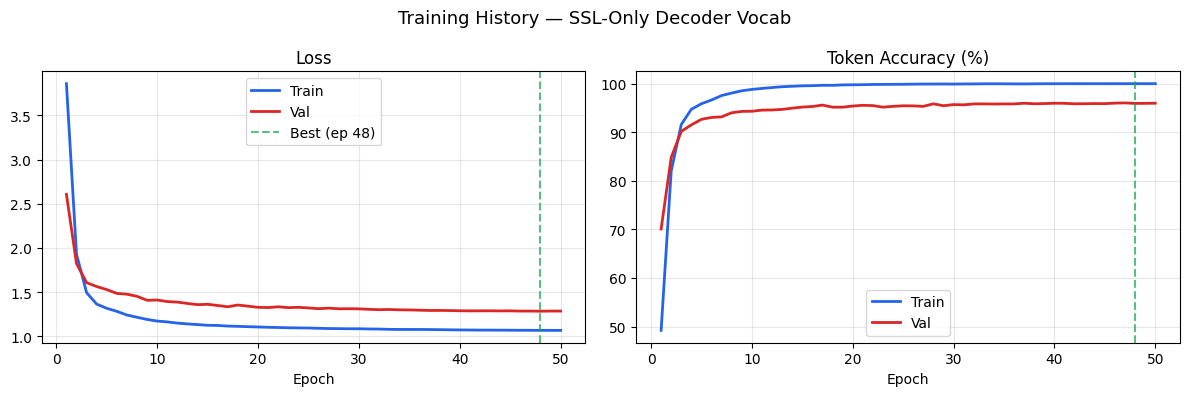

Top 5 epochs by Val Loss:
 epoch  train_loss  val_loss  train_acc  val_acc
    48    1.067999  1.284115   0.999835 0.959240
    50    1.067453  1.285711   0.999833 0.959607
    46    1.068774  1.285830   0.999819 0.959809
    49    1.067736  1.286240   0.999818 0.959338
    47    1.068414  1.286260   0.999826 0.960211


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training History — SSL-Only Decoder Vocab", fontsize=13)
epochs = history["epoch"]

axes[0].plot(epochs, history["train_loss"], label="Train", color="#2563eb", lw=2)
axes[0].plot(epochs, history["val_loss"],   label="Val",   color="#dc2626", lw=2)
axes[0].axvline(best_epoch, color="#16a34a", linestyle="--", alpha=0.7,
                label=f"Best (ep {best_epoch})")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history["train_acc"]],
             label="Train", color="#2563eb", lw=2)
axes[1].plot(epochs, [a*100 for a in history["val_acc"]],
             label="Val",   color="#dc2626", lw=2)
axes[1].axvline(best_epoch, color="#16a34a", linestyle="--", alpha=0.7)
axes[1].set_title("Token Accuracy (%)"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG.OUTPUT_DIR}/training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

df_h = pd.DataFrame(history)
print("Top 5 epochs by Val Loss:")
print(df_h.nsmallest(5, "val_loss")
         [["epoch","train_loss","val_loss","train_acc","val_acc"]]
         .to_string(index=False))


In [12]:
ckpt = torch.load(f"{CFG.MODEL_DIR}/best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"\u2713 Best model loaded (epoch {ckpt['epoch']}, "
      f"val_loss={ckpt['val_loss']:.4f}, "
      f"val_acc={ckpt['val_acc']*100:.2f}%)")

@torch.no_grad()
def beam_search(memory, attn_mask, beam_size=4):
    beams = [([CFG.BOS_IDX], 0.0)]
    done  = []
    for _ in range(CFG.MAX_TGT_LEN):
        cands = []
        for seq, score in beams:
            tgt     = torch.tensor([seq], device=DEVICE)
            dec_out = model.decode_step(tgt, memory, attn_mask)
            logits  = model.output_proj(dec_out[:, -1, :]).squeeze(0)
            lp      = F.log_softmax(logits, dim=-1)
            top_v, top_i = lp.topk(min(beam_size, ssl_vocab.size - 1))
            for v, i in zip(top_v.tolist(), top_i.tolist()):
                cands.append((seq + [i], score + v))
        cands.sort(key=lambda x: x[1], reverse=True)
        beams = []
        for seq, sc in cands[:beam_size * 2]:
            if seq[-1] == CFG.EOS_IDX: done.append((seq[1:-1], sc / max(len(seq)-2, 1)))
            else: beams.append((seq, sc))
            if len(beams) >= beam_size: break
        if not beams: break
    if done:
        done.sort(key=lambda x: x[1], reverse=True)
        return done[0][0]
    return beams[0][0][1:] if beams else []

def translate(text: str, beam_size: int = 4) -> Dict:
    model.eval()
    enc = enc_tokenizer(text, max_length=CFG.MAX_SRC_LEN, padding="max_length", truncation=True, return_tensors="pt").to(DEVICE)
    memory = model.encode(enc["input_ids"], enc["attention_mask"])
    indices = beam_search(memory, enc["attention_mask"], beam_size)
    gloss_words = ssl_vocab.decode(indices)
    ssl_tokens = [{"word": w, "sign_id": ssl_vocab.word_to_ssl_id(w)} for w in gloss_words]
    return {"source": text, "gloss_words": gloss_words, "ssl_tokens": ssl_tokens, "ssl_string": " | ".join(f"{t['sign_id']}:{t['word']}" for t in ssl_tokens)}

print("\u2713 Translator ready for M2M100 architecture")

✓ Best model loaded (epoch 48, val_loss=1.2841, val_acc=95.92%)
✓ Translator ready for M2M100 architecture


In [13]:
rows = []
print(f"Evaluating {len(test_pairs)} test sentences ...\n")
print("─" * 70)

eval_start = time.time()
for i, pair in enumerate(test_pairs):
    pred = translate(pair["source"])

    correct_words  = pair["gloss_words"]
    correct_ids    = pair["target_ids"]
    pred_words     = pred["gloss_words"]
    pred_ids       = [t["sign_id"] for t in pred["ssl_tokens"]]

    correct_string = " | ".join(
        f"{tid}:{w}" for tid, w in zip(correct_ids, correct_words))

    word_overlap = len(set(correct_words) & set(pred_words)) / max(len(correct_words), 1)
    id_overlap   = len(set(correct_ids)   & set(pred_ids))   / max(len(correct_ids),   1)
    min_len      = min(len(correct_words), len(pred_words))
    pos_acc      = sum(1 for j in range(min_len)
                       if correct_words[j] == pred_words[j]) / max(len(correct_words), 1)
    exact        = int(correct_words == pred_words)

    rows.append({
        "source"           : pair["source"],
        "correct_words"    : " | ".join(correct_words),
        "predicted_words"  : " | ".join(pred_words),
        "correct_ids"      : " | ".join(str(x) for x in correct_ids),
        "predicted_ids"    : " | ".join(str(x) for x in pred_ids),
        "correct_string"   : correct_string,
        "predicted_string" : pred["ssl_string"],
        "word_overlap_%"   : round(word_overlap * 100, 1),
        "id_overlap_%"     : round(id_overlap   * 100, 1),
        "pos_accuracy_%"   : round(pos_acc      * 100, 1),
        "exact_match"      : exact,
        "correct_len"      : len(correct_words),
        "predicted_len"    : len(pred_words),
    })

    print(f"[{i+1}/{len(test_pairs)}] {pair['source']}")
    print(f"  Correct   : {correct_string}")
    print(f"  Predicted : {pred['ssl_string']}")
    print(f"  Overlap   : word={word_overlap*100:.0f}%  "
          f"id={id_overlap*100:.0f}%  exact={'✓' if exact else '✗'}")
    print()
eval_secs = time.time() - eval_start
print(f"Eval: {eval_secs:.2f}s  |  Avg: {eval_secs/len(test_pairs)*1000:.1f}ms/sentence")

df = pd.DataFrame(rows)
df.to_csv(f"{CFG.OUTPUT_DIR}/test_results.csv", index=False, encoding="utf-8")

print("=" * 55)
print("  TEST RESULTS")
print("=" * 55)
print(f"  Sentences         : {len(df)}")
print(f"  Word Overlap      : {df['word_overlap_%'].mean():.2f}%")
print(f"  SSL ID Overlap    : {df['id_overlap_%'].mean():.2f}%")
print(f"  Position Accuracy : {df['pos_accuracy_%'].mean():.2f}%")
print(f"  Exact Match       : {df['exact_match'].mean()*100:.2f}%")
print("=" * 55)
print(f"\n✓ Results → {CFG.OUTPUT_DIR}/test_results.csv")


Evaluating 1653 test sentences ...

──────────────────────────────────────────────────────────────────────
[1/1653] කෞෂල්‍ය හෙට වතුර බොනවා
  Correct   : 4:<FS> | 478:ක් | 1700:- | 561:ගයනු කිත්ත | 1700:- | 1455:ෂ් | 1700:- | 133:අ | 1700:- | 1292:ල් | 1700:- | 1223:යංශය | 1581:හෙට | 1336:වතුර | 1103:බොනවා
  Predicted : 4:<FS> | 478:ක් | 1700:- | 561:ගයනු කිත්ත | 1700:- | 1455:ෂ් | 1700:- | 133:අ | 1700:- | 1292:ල් | 1700:- | 1223:යංශය | 1581:හෙට | 1336:වතුර | 1103:බොනවා
  Overlap   : word=73%  id=73%  exact=✓

[2/1653] ක්‍රිශාන්ත අද බත් උයනවා
  Correct   : 4:<FS> | 478:ක් | 1700:- | 1239:රකාරාංශය | 1700:- | 296:ඉ | 1700:- | 1452:ශ් | 1700:- | 241:ආ | 1700:- | 862:න් | 1700:- | 739:ත් | 1700:- | 133:අ | 166:අද | 1054:බත් | 375:උයනවා
  Predicted : 4:<FS> | 478:ක් | 1700:- | 1239:රකාරාංශය | 1700:- | 296:ඉ | 1700:- | 1452:ශ් | 1700:- | 241:ආ | 1700:- | 862:න් | 1700:- | 739:ත් | 1700:- | 133:අ | 166:අද | 1054:බත් | 375:උයනවා
  Overlap   : word=68%  id=68%  exact=✓

[3/1653] හැමවෙලේම
  Corr

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# TRANSLATE UNSEEN SINHALA SENTENCES
# Every predicted token is GUARANTEED to be a valid SSL sign token.
# No fuzzy matching needed — out-of-vocab is architecturally impossible.
# ═══════════════════════════════════════════════════════════════════════

UNSEEN_SENTENCES = [
    "ඔයා කොහෙද ඉන්නේ",
    "මම ගෙදර යනවා",
    "ඔයාගේ නම මොකක්ද",
    "අපි හෙට ගමට යමු",
    "ඔබට ස්තූතියි",
    "මම 1ට පාසලට එනවා",
    "මම එකට පාසලට එනවා",
    "අපි සියලු දෙනාම නිමල් සමග යනවා",
    "කුමාර හෙට ගෙදර යනවා",
    "ඇය හෙට කතරගම යනවා",
    "ඔහු ඊයෙ ගම්පහ ගියා",
    "ගුරුවරයා අඹ දහයක් ගෙනාවා"
    "අපි හෙට පාසලට එනවද?",
    "අපි හෙට තැබිලි බොමු"
    # ← add more here
]

print("=" * 65)
print("  UNSEEN SENTENCE PREDICTIONS  (SSL-only decoder)")
print("=" * 65)

for text in UNSEEN_SENTENCES:
    result = translate(text, beam_size=4)
    print(f"\nSource     : {result['source']}")
    print(f"SSL output : {result['ssl_string']}")
    print(f"Tokens     :")
    for tok in result["ssl_tokens"]:
        print(f"  {tok['word']:20s} → Sign ID: {tok['sign_id']}")
    print("-" * 65)


def predict_single(sinhala_text: str) -> Dict:
    """Translate a single Sinhala sentence. Usage: predict_single('ඔයා හොඳද')"""
    result = translate(sinhala_text, beam_size=4)
    print(f"Source : {result['source']}")
    print(f"Output : {result['ssl_string']}")
    return result

# predict_single("ඔයා හොඳද")


  UNSEEN SENTENCE PREDICTIONS  (SSL-only decoder)

Source     : ඔයා කොහෙද ඉන්නේ
SSL output : 408:ඔබ | 567:කොහේද | 316:ඉන්නවා
Tokens     :
  ඔබ                   → Sign ID: 408
  කොහේද                → Sign ID: 567
  ඉන්නවා               → Sign ID: 316
-----------------------------------------------------------------

Source     : මම ගෙදර යනවා
SSL output : 1128:මම | 636:ගෙදර | 1229:යනවා
Tokens     :
  මම                   → Sign ID: 1128
  ගෙදර                 → Sign ID: 636
  යනවා                 → Sign ID: 1229
-----------------------------------------------------------------

Source     : ඔයාගේ නම මොකක්ද
SSL output : 409:ඔබගේ | 857:නම් | 1212:මොකක්ද
Tokens     :
  ඔබගේ                 → Sign ID: 409
  නම්                  → Sign ID: 857
  මොකක්ද               → Sign ID: 1212
-----------------------------------------------------------------

Source     : අපි හෙට ගමට යමු
SSL output : 185:අපි | 1581:හෙට | 4:<FS> | 296:ඉ | 1700:- | 1551:හ් | 1700:- | 133:අ | 1700:- | 1597:ළ් | 1700:- | 1